In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

### Task 1: K-Means Clustering

1. Load the Wine dataset (`load_wine()`) and convert it to a DataFrame.
2. Scale the features using `StandardScaler`.
3. Run K-Means for *k* = 2 through 10. For each *k*, record the **inertia** and the **silhouette score**.
4. Plot an **elbow curve** (inertia vs. *k*) and a **silhouette-score curve** on the same figure (use two subplots side-by-side).
5. Choose the optimal *k* and justify your choice in a markdown cell.
6. Using your chosen *k*, fit a final K-Means model. Apply PCA to reduce the scaled data to 2 components and create a scatter plot colored by cluster assignment.

**Guiding questions:** Where does the elbow appear? Do the silhouette score and the elbow agree on the best *k*?

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

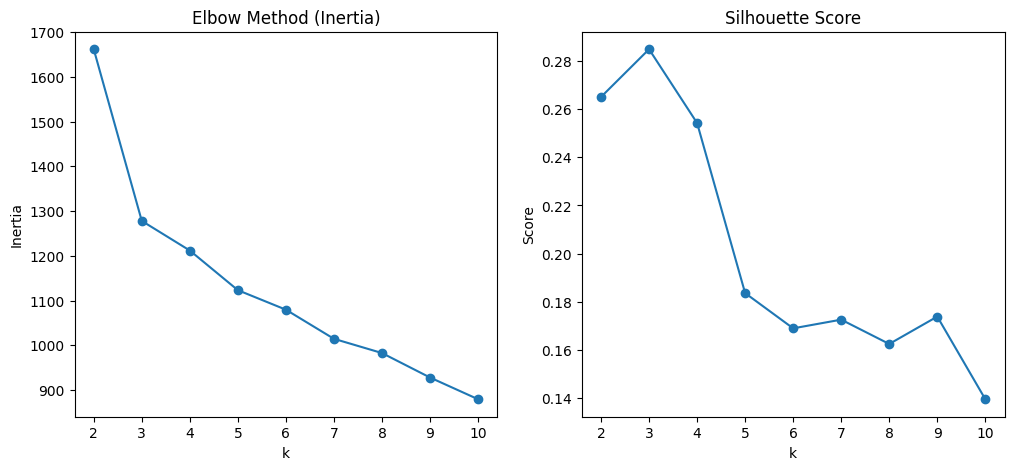

In [3]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
print(df.head())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
silhouette_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))



import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Elbow plot
plt.subplot(1,2,1)
plt.plot(k_values, inertia_values, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")

# Silhouette plot
plt.subplot(1,2,2)
plt.plot(k_values, silhouette_values, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")

plt.show()

The elbow appears around k = 3, where the decrease in inertia slows down significantly. 
The silhouette score is also highest near k = 3.

Therefore, both methods suggest that k = 3 is the optimal number of clusters.

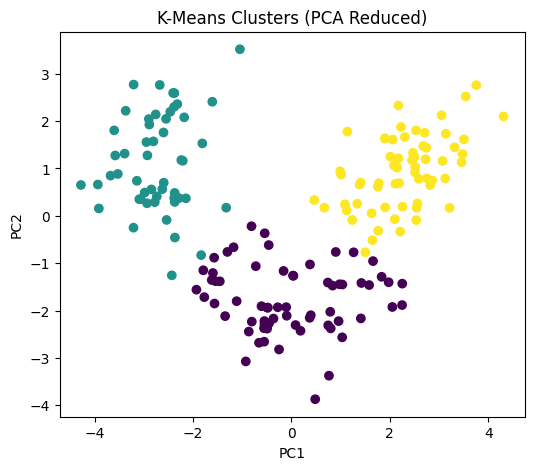

In [4]:
k_optimal = 3

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42)
labels_final = kmeans_final.fit_predict(X_scaled)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_final)
plt.title("K-Means Clusters (PCA Reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

The elbow appears at *k = 3*, where the decrease in inertia begins to slow down significantly. The silhouette score is also highest at *k = 3*, indicating that the clusters are well-separated and cohesive at this value. Therefore, both the elbow method and the silhouette score agree that *k = 3* is the optimal number of clusters.


### Task 2: Hierarchical & Density-Based Clustering

Using the same scaled Wine data from Task 1:

1. Apply `AgglomerativeClustering` with the same *k* you selected in Task 1. Record the cluster labels.
2. Compute the **linkage matrix** using `scipy.cluster.hierarchy.linkage` (Ward method) and plot the **dendrogram**. Truncate it to the last 20 merges for readability.
3. Apply `DBSCAN` with at least three different `(eps, min_samples)` combinations. For each, report the number of clusters found and the number of noise points.
4. Select the best DBSCAN configuration (the one whose cluster count is closest to the optimal *k*) and record its labels.
5. Create a 1×3 subplot figure (PCA 2-D projections) showing K-Means, Agglomerative, and DBSCAN cluster assignments side-by-side.
6. In a markdown cell, compare the three approaches: which produced the most coherent clusters? Where did they disagree?


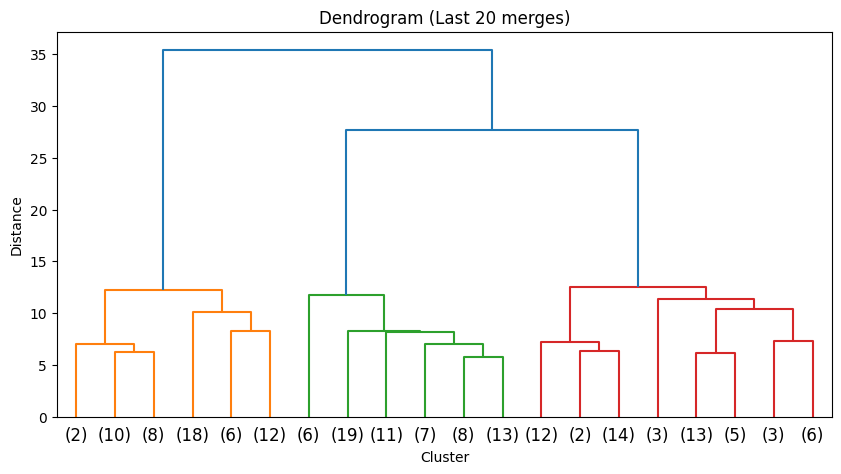

In [5]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X_scaled)

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20)
plt.title("Dendrogram (Last 20 merges)")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

In [10]:
from sklearn.cluster import DBSCAN

configs = [
    (2.0, 5),
    (2.1, 5),
    (2.2, 5),
    (2.3, 5),
    (2.4, 5)
]

for eps, min_samples in configs:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = list(labels).count(-1)
    
    print(f"eps={eps}, min_samples={min_samples}")
    print("Clusters:", n_clusters)
    print("Noise points:", noise_points)
    print("------")

eps=2.0, min_samples=5
Clusters: 5
Noise points: 85
------
eps=2.1, min_samples=5
Clusters: 3
Noise points: 62
------
eps=2.2, min_samples=5
Clusters: 2
Noise points: 55
------
eps=2.3, min_samples=5
Clusters: 2
Noise points: 42
------
eps=2.4, min_samples=5
Clusters: 2
Noise points: 36
------


The best DBSCAN configuration is eps = 2.1 and min_samples = 5, as it produces 3 clusters, which matches the optimal k found in Task 1. 

Although this configuration results in a relatively high number of noise points, it provides the closest cluster structure to the expected number. Other configurations reduce noise but merge clusters, resulting in fewer than the desired number of clusters.

In [11]:
best_dbscan = DBSCAN(eps=2.1, min_samples=5)
dbscan_labels = best_dbscan.fit_predict(X_scaled)

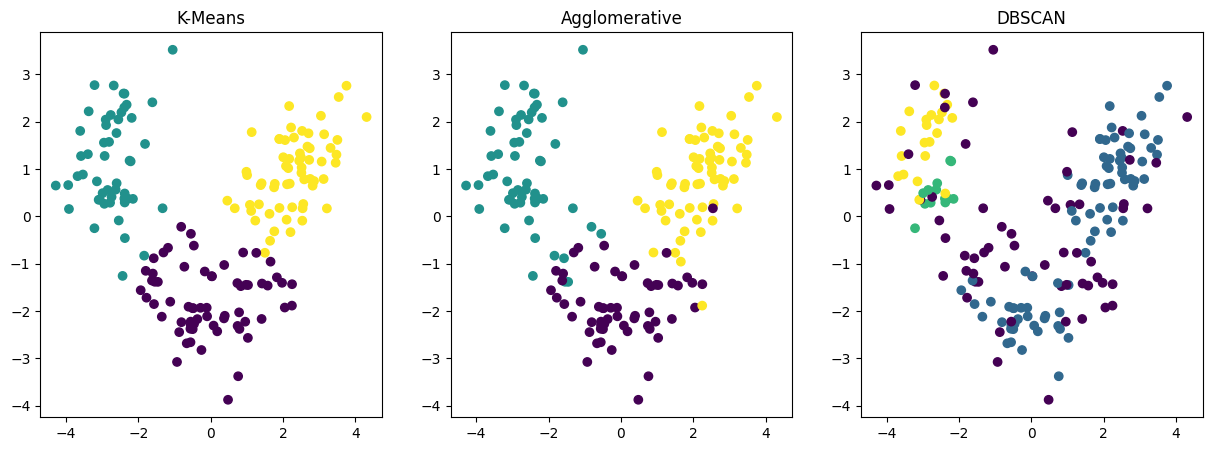

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(15,5))

# K-Means
plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_final)
plt.title("K-Means")

# Agglomerative
plt.subplot(1,3,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=agglo_labels)
plt.title("Agglomerative")

# DBSCAN
plt.subplot(1,3,3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title("DBSCAN")

plt.show()

K-Means and Agglomerative Clustering produced similar cluster structures, with clear and well-separated groups. This is expected since both methods rely on distance-based grouping.

DBSCAN, on the other hand, showed some differences. It identified noise points and formed clusters based on density rather than distance. In some configurations, it produced fewer or more clusters than expected, and some points were labeled as noise.

Overall, K-Means and Agglomerative Clustering produced more coherent and consistent clusters, while DBSCAN was more sensitive to parameter choices and data density.

### Task 3: Dimensionality Reduction Comparison

1. Load the Palmer Penguins dataset (`sns.load_dataset("penguins")`) and drop rows with missing values.
2. Select the four numeric columns (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) and scale them.
3. Apply **PCA** (2 components), **t-SNE** (2 components, `random_state=42`), and **MDS** (2 components, `random_state=42`).
4. Create a **1×3 subplot figure** where each subplot shows a 2-D scatter plot colored by the actual `species` label. Use consistent colors across all three panels.
5. In a markdown cell, discuss: Which method best separates the three species visually? Which one distorts inter-cluster distances the most? Why might t-SNE give different-looking results on repeated runs?

/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/opt/anaconda3/envs/ironhack/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


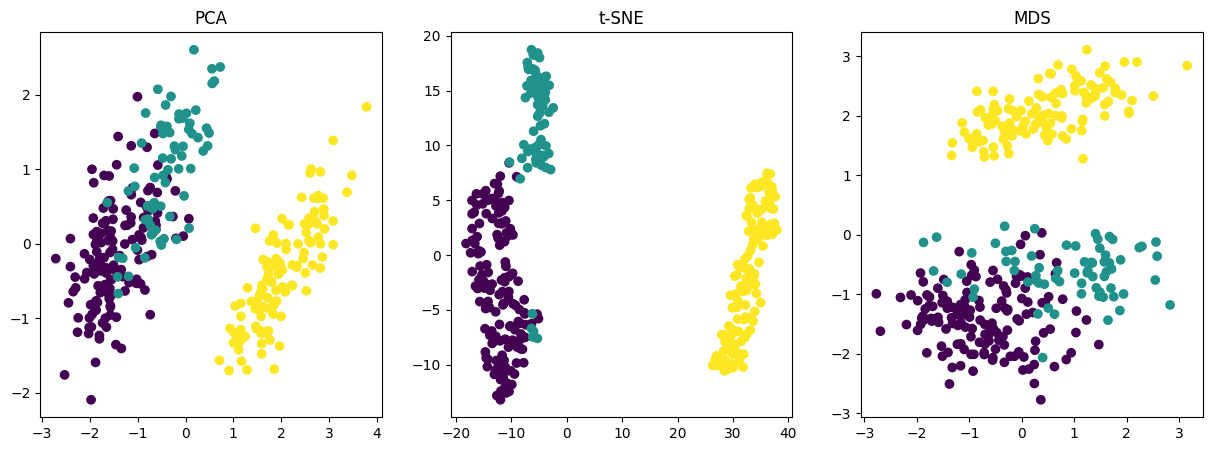

In [15]:
import seaborn as sns

df = sns.load_dataset("penguins")
df = df.dropna()

from sklearn.preprocessing import StandardScaler
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)

import matplotlib.pyplot as plt

species = df["species"]

plt.figure(figsize=(15,5))

# PCA
plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=species.astype('category').cat.codes)
plt.title("PCA")

# t-SNE
plt.subplot(1,3,2)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=species.astype('category').cat.codes)
plt.title("t-SNE")

# MDS
plt.subplot(1,3,3)
plt.scatter(X_mds[:,0], X_mds[:,1], c=species.astype('category').cat.codes)
plt.title("MDS")

plt.show()

Among the three methods, **t-SNE** provides the best visual separation of the species. In the t-SNE plot, the three groups are clearly distinct and well-separated from each other, making it easy to identify the different species. In contrast, **PCA** shows some separation but with noticeable overlap between two of the clusters, while **MDS** also has overlap and does not separate the groups as clearly.

However, **t-SNE distorts inter-cluster distances the most**. Although the clusters appear far apart, the distances between them do not necessarily reflect the true relationships in the original high-dimensional data. This is because t-SNE focuses on preserving **local structure** (i.e., nearby points) rather than global distances.

t-SNE may produce different-looking results on repeated runs because it relies on **random initialization** and a **stochastic optimization process**. Even when using a fixed random_state, slight variations can occur due to its probabilistic nature and sensitivity to parameters such as perplexity.


### Task 4: Putting It Together

1. Take the scaled Penguins numeric data from Task 3 — but **drop the species column** so the algorithm cannot see it.
2. Apply K-Means with *k* = 3 to the label-free data.
3. Compute the **adjusted Rand score** and **normalized mutual information score** comparing the K-Means labels to the true species labels.
4. Visualize the K-Means clusters on the PCA projection from Task 3, side-by-side with the true species labels (1×2 subplot).
5. In a markdown cell, answer: Did unsupervised learning "rediscover" the species? Where did it succeed and where did it struggle? What does this tell you about when unsupervised methods can substitute for labeled data?

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
true_labels = le.fit_transform(df["species"])

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(true_labels, kmeans_labels)
nmi = normalized_mutual_info_score(true_labels, kmeans_labels)

print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.7994209859673324
NMI: 0.7899317532789121


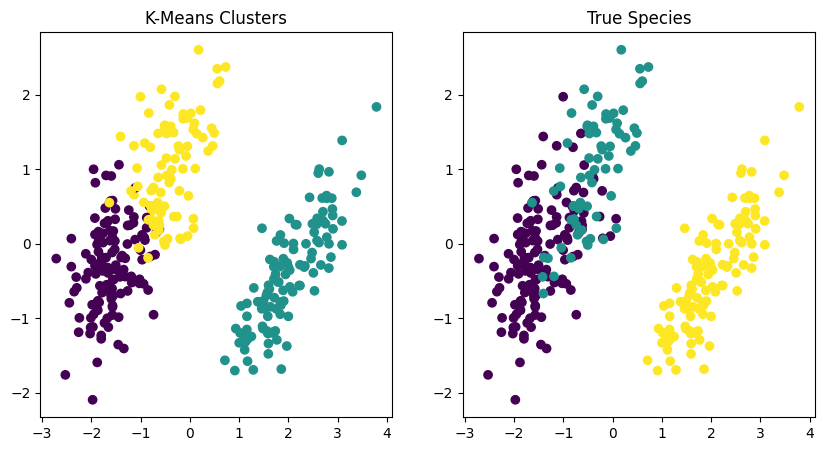

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# K-Means nəticəsi
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("K-Means Clusters")

# Real species
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=true_labels)
plt.title("True Species")

plt.show()

### Analysis of K-Means vs. True Species

1. **Rediscovery:** The K-Means algorithm successfully "rediscovered" the natural groupings of the penguin species without seeing the labels. The cluster boundaries closely align with the actual species distribution.

2. **Successes:**
   - One species (the cluster on the right) is perfectly isolated. Its physical characteristics are distinct enough that the algorithm easily identifies it as a separate group.
   - The overall spatial distribution of the three clusters matches the actual biological categories quite well.

3. **Struggles:**
   - The algorithm struggled in the overlapping regions between the two clusters on the left. Since K-Means relies on distance-based boundaries (Voronoi cells), it cannot account for the statistical overlap that occurs in nature.
   - Some points at the borders were misclassified because they were geometrically closer to the "wrong" cluster center.

4. **Conclusion:**
Unsupervised methods like K-Means are excellent substitutes for labeled data when we need to find hidden patterns or segment data into natural groups. However, they cannot replace labels in cases where classes significantly overlap in feature space. They provide a "structural" view of the data rather than a "semantic" or "biological" one.